In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data=pd.DataFrame(
    {
        "patient_name":["sai","vivek","vijay","mock","uday"],
        "age":[20,40,50,32,55],
        "condition":["stable","critical","serious","serious","critical"],
        "oxygen_level":[95,78,80,87,70]

    }
)
total_beds = 3

def calculate_priority(row):

    if row["condition"] == "critical":
        condition_weight = 50
    elif row["condition"] == "serious":
        condition_weight = 30
    else:
        condition_weight = 10

    if row["age"] > 60:
        age_factor = 20
    elif row["age"] >= 40:
        age_factor = 10
    else:
        age_factor = 5

    score = (100 - row["oxygen_level"]) + condition_weight + age_factor

    return score

data["Priority Score"] = data.apply(calculate_priority, axis=1)

data = data.sort_values(by="Priority Score", ascending=False)

data["Bed Status"] = "No Bed Available"

data.iloc[:total_beds, data.columns.get_loc("Bed Status")] = "Bed Allocated"

def prescription(row):

    if row["condition"] == "critical":
        return "Assign Ventilator"

    elif row["condition"] == "serious":
        return "Provide Oxygen"

    else:
        return "Tablets"

data["Prescription"] = data.apply(prescription, axis=1)

print("\nFinal Hospital Allocation Report:\n")
print(data)

no_bed_patients = data[data["Bed Status"] == "No Bed Available"]

print("\nPatients Without Beds:\n")

if len(no_bed_patients) > 0:
    print(no_bed_patients[[
        "patient_name",
        "condition",
        "Priority Score"
    ]])
else:
    print("All patients received beds.")


Final Hospital Allocation Report:

  patient_name  age condition  oxygen_level  Priority Score        Bed Status  \
4         uday   55  critical            70              90     Bed Allocated   
1        vivek   40  critical            78              82     Bed Allocated   
2        vijay   50   serious            80              60     Bed Allocated   
3         mock   32   serious            87              48  No Bed Available   
0          sai   20    stable            95              20  No Bed Available   

        Prescription  
4  Assign Ventilator  
1  Assign Ventilator  
2     Provide Oxygen  
3     Provide Oxygen  
0            Tablets  

Patients Without Beds:

  patient_name condition  Priority Score
3         mock   serious              48
0          sai    stable              20


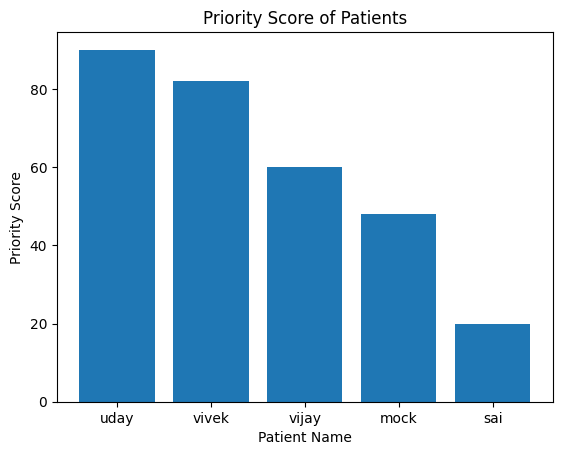

In [22]:
plt.bar(data["patient_name"], data["Priority Score"])
plt.xlabel("Patient Name")
plt.ylabel("Priority Score")
plt.title("Priority Score of Patients")
plt.show()
